<a href="https://colab.research.google.com/github/blankqspace/homework_compling_course/blob/main/cnn_homework__Artamonova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Домашка

### Задание 1 (8 баллов)
Обучите модель с минимум 15 слоями, где у каждого слоя разные параметры (Dropout, Conv1d и Pooling, Linear считаются слоями, остальное нет, но их тоже можно использовать). Как минимум 4 слоя должны быть наложены друг на друга и как минимум 2 параллельных слоя (последовательности слоев). Должен быть хотя бы один слой каждого типа.

Вместо графиков f1 меры сделайте графики для точности и полноты. Пообучайте модель подольше, чтобы посмотреть на то как изменяются метрики.

Напишите короткую функцию для предсказания класса отдельного текста. Возьмите любой новый новостной текст и предскажите его класс. Правильное ли предсказание?

Советы: Начните с небольших сетей и постепенно добавляйте слои и увеличивайте параметры, не пытайтесь сразу собрать все слои. Иногда кернел может крашиться просто так или из-за слишком больших матриц. Помимо уменьшения параметров, вы можете попробовать уменьшить batch size.


### Задание 2 (2 балла)
Обучите нейросеть со сверточными слоями с архитектурой похожей на Unet - https://en.wikipedia.org/wiki/U-Net
Вы можете работать как с текстами так и с картинками.

Не нужно воспроизводить все в точности, главное, чтобы было сокращение длины последовательности (или height, weight в картинках) с помощью CNN, а затем обратное увеличение до изначальной с residual связями между промежуточными шагами с одинаковыми размерностями.
Изменений размерности должно быть хотя бы 3 и соответственно residual связей тоже.

Для повышения размерности используйте https://docs.pytorch.org/docs/stable/generated/torch.nn.Upsample.html
Полученная модель должна давать ненулевое качество.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
import pandas as pd
import numpy as np
from string import punctuation
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score

In [4]:
data = pd.read_csv('lenta_40k.csv.zip')

In [5]:
def preprocess(text):
    tokens = text.lower().split()
    tokens = [token.strip(punctuation) for token in tokens]
    return tokens

vocab = Counter()
filtered_vocab = set()

for text in data.text:
    vocab.update(preprocess(text))

for word in vocab:
    if vocab[word] > 30:
        filtered_vocab.add(word)

In [6]:
print("Vocab:", len(vocab))
print("Filtered vocab:",len(filtered_vocab))

Vocab: 354611
Filtered vocab: 24091


In [7]:
word2id = {'PAD':0}

for word in filtered_vocab:
    word2id[word] = len(word2id)

id2word = {i:word for word, i in word2id.items()}

In [8]:
class Dataset(torch.utils.data.Dataset):

    def __init__(self, word2id, MAX_LEN, texts, targets):

        self.texts = [torch.LongTensor([word2id[w] for w in self.preprocess(t) if w in word2id][:MAX_LEN]) for t in texts]
        self.texts = torch.nn.utils.rnn.pad_sequence(self.texts, batch_first=True)

        self.word2id = word2id
        self.MAX_LEN = MAX_LEN
        self.length = len(texts)

        self.target = torch.LongTensor(targets)

    def __len__(self):
        return self.length

    def __getitem__(self, index):

        ids = self.texts[index]
        y = self.target[index]

        return ids, y

    def preprocess(self, text):
        tokens = text.lower().split()
        tokens = [token.strip(punctuation) for token in tokens]
        tokens = [token for token in tokens if token]
        return tokens

In [9]:
MAX_LEN = 200

In [10]:
texts = data.text.values
id2label = {i:l for i,l in enumerate(set(data.topic))}
label2id = {l:i for i,l in id2label.items()}
targets = [label2id[l] for l in data.topic]

train_texts, valid_texts, train_targets, valid_targets = train_test_split(texts, targets, test_size=0.05)

training_set = Dataset(word2id, MAX_LEN, train_texts, train_targets)
training_generator = torch.utils.data.DataLoader(training_set, batch_size=256, shuffle=True, )
valid_set = Dataset(word2id, MAX_LEN, valid_texts, valid_targets)
valid_generator = torch.utils.data.DataLoader(valid_set, batch_size=256, shuffle=True)

In [54]:
class ConvBNAct1d(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 7,
        stride: int = 1,
        activation: nn.Module | None = None,
    ):
        super().__init__()
        # if kernel_size % 2 == 0:
        #     raise ValueError("Use an odd kernel_size to preserve length with symmetric padding.")
        # if stride != 1:
        #     raise ValueError("This block assumes stride=1 to preserve length with symmetric padding.")

        self.conv = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=kernel_size // 2,
            bias=False,
        )
        self.bn = nn.BatchNorm1d(out_channels)
        self.act = activation if activation is not None else nn.LeakyReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.bn(self.conv(x)))


In [56]:
class NewsCNN(nn.Module):
    def __init__(
        self,
        output_dim: int,
        vocab_size: int,
        emb_dim: int = 200,
        max_len: int = 200,
        hidden_fc: int = 256,
        dropout_p: float = 0.1,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.emb_dropout = nn.Dropout(dropout_p)

        # параллельный слой 1
        self.branch1 = nn.Sequential(
            ConvBNAct1d(emb_dim, 64, kernel_size=3),   # 1
            ConvBNAct1d(64 , 64, kernel_size=3),        # 2
            nn.MaxPool1d(2),                           # 3
            nn.Dropout(dropout_p),                     # 4
            ConvBNAct1d(64, 64, kernel_size=3),       # 5
            ConvBNAct1d(64, 64, kernel_size=3),      # 6
            nn.MaxPool1d(2),                           # 7
            nn.Dropout(dropout_p),                     # 8
        )

        #  параллельный слой 2
        self.branch2 = nn.Sequential(
            ConvBNAct1d(emb_dim, 64, kernel_size=5),   # 9
            ConvBNAct1d(64, 64, kernel_size=5),        #10
            nn.MaxPool1d(2),                           #11
            nn.Dropout(dropout_p),                     #12
            ConvBNAct1d(64, 64, kernel_size=5),       #13
            ConvBNAct1d(64, 64, kernel_size=5),      #14
            nn.MaxPool1d(2),                           #15
            nn.Dropout(dropout_p),                     #16
        )

        self.fc = nn.Linear(64*2, hidden_fc)
        self.fc_out = nn.Linear(hidden_fc, output_dim)
        self.act = nn.LogSoftmax(dim=1)

    def forward(self, text):
        x = self.embedding(text)
        x = self.emb_dropout(x)
        x = x.permute(0, 2, 1)

        b1 = self.branch1(x)
        b2 = self.branch2(x)

        b1 = torch.max(b1, dim=2)[0]
        b2 = torch.max(b2, dim=2)[0]

        x = torch.cat([b1, b2], dim=1)
        x = torch.relu(self.fc(x))
        x = self.fc_out(x)
        return self.act(x)


In [57]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = NewsCNN(
    output_dim=len(label2id),
    vocab_size=len(word2id),
    emb_dim=200,
    max_len=200,
    hidden_fc=256,
    dropout_p=0.1,
).to(device)

optimizer = optim.Adam(model.parameters(), lr=5e-4)
criterion = nn.NLLLoss().to(device)

In [58]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    y_true, y_pred = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        y_true.extend(y.cpu().numpy())
        y_pred.extend(out.argmax(1).cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred, average="macro")
    return acc, rec

def eval_epoch(model, loader, criterion):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(out.argmax(1).cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred, average="macro")
    return acc, rec

In [59]:
train_accs, train_recs = [], []
val_accs, val_recs = [], []

for epoch in range(25):
    tr_acc, tr_rec = train_epoch(model, training_generator, optimizer, criterion)
    va_acc, va_rec = eval_epoch(model, valid_generator, criterion)

    train_accs.append(tr_acc)
    train_recs.append(tr_rec)
    val_accs.append(va_acc)
    val_recs.append(va_rec)

    print(
        f"Epoch {epoch+1}: "
        f"Train acc={tr_acc:.4f}, rec={tr_rec:.4f} | "
        f"Val acc={va_acc:.4f}, rec={va_rec:.4f}"
    )

Epoch 1: Train acc=0.3031, rec=0.0988 | Val acc=0.4509, rec=0.1879
Epoch 2: Train acc=0.5294, rec=0.2217 | Val acc=0.6019, rec=0.3073
Epoch 3: Train acc=0.6299, rec=0.3036 | Val acc=0.6461, rec=0.3525
Epoch 4: Train acc=0.6832, rec=0.3580 | Val acc=0.6578, rec=0.3730
Epoch 5: Train acc=0.7236, rec=0.4010 | Val acc=0.6826, rec=0.4297
Epoch 6: Train acc=0.7571, rec=0.4396 | Val acc=0.6830, rec=0.4362
Epoch 7: Train acc=0.7826, rec=0.4736 | Val acc=0.7060, rec=0.4598
Epoch 8: Train acc=0.8073, rec=0.5031 | Val acc=0.6803, rec=0.4535
Epoch 9: Train acc=0.8293, rec=0.5285 | Val acc=0.7151, rec=0.4865
Epoch 10: Train acc=0.8492, rec=0.5539 | Val acc=0.7101, rec=0.5212
Epoch 11: Train acc=0.8627, rec=0.5781 | Val acc=0.6849, rec=0.4784
Epoch 12: Train acc=0.8842, rec=0.6010 | Val acc=0.7087, rec=0.4848
Epoch 13: Train acc=0.8965, rec=0.6208 | Val acc=0.7169, rec=0.4830
Epoch 14: Train acc=0.9058, rec=0.6374 | Val acc=0.7146, rec=0.4908
Epoch 15: Train acc=0.9167, rec=0.6647 | Val acc=0.7115, 

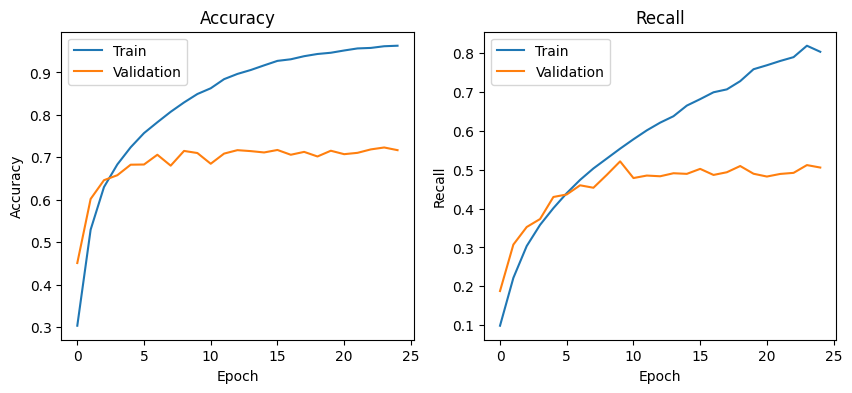

In [60]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_recs, label="Train")
plt.plot(val_recs, label="Validation")
plt.title("Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.legend()

plt.show()

Что было в первый раз, когда я обучала (я забыла сохранить графики :((( )
```
Epoch 1: Train acc=0.3198, rec=0.1175 | Val acc=0.4675, rec=0.2330
Epoch 2: Train acc=0.5699, rec=0.2501 | Val acc=0.6050, rec=0.3165
Epoch 3: Train acc=0.6526, rec=0.3164 | Val acc=0.5947, rec=0.3688
Epoch 4: Train acc=0.6980, rec=0.3666 | Val acc=0.6429, rec=0.3859
Epoch 5: Train acc=0.7319, rec=0.4028 | Val acc=0.5830, rec=0.3838
Epoch 6: Train acc=0.7586, rec=0.4276 | Val acc=0.6749, rec=0.4467
Epoch 7: Train acc=0.7833, rec=0.4574 | Val acc=0.6605, rec=0.4561
Epoch 8: Train acc=0.8056, rec=0.4814 | Val acc=0.6650, rec=0.4632
Epoch 9: Train acc=0.8233, rec=0.4988 | Val acc=0.6564, rec=0.4714
Epoch 10: Train acc=0.8424, rec=0.5241 | Val acc=0.7092, rec=0.4923
Epoch 11: Train acc=0.8561, rec=0.5394 | Val acc=0.6465, rec=0.4744
Epoch 12: Train acc=0.8709, rec=0.5588 | Val acc=0.6916, rec=0.5160
Epoch 13: Train acc=0.8841, rec=0.5779 | Val acc=0.6943, rec=0.5064
Epoch 14: Train acc=0.8929, rec=0.5901 | Val acc=0.6506, rec=0.5128
Epoch 15: Train acc=0.9023, rec=0.6122 | Val acc=0.6371, rec=0.5184
Epoch 16: Train acc=0.9095, rec=0.6195 | Val acc=0.5987, rec=0.4715
Epoch 17: Train acc=0.9173, rec=0.6278 | Val acc=0.6307, rec=0.4839
Epoch 18: Train acc=0.9221, rec=0.6352 | Val acc=0.6028, rec=0.4914
Epoch 19: Train acc=0.9266, rec=0.6545 | Val acc=0.6772, rec=0.5230
Epoch 20: Train acc=0.9320, rec=0.6630 | Val acc=0.6366, rec=0.5069
Epoch 21: Train acc=0.9354, rec=0.6660 | Val acc=0.6317, rec=0.5104
Epoch 22: Train acc=0.9410, rec=0.6725 | Val acc=0.6402, rec=0.5051
Epoch 23: Train acc=0.9422, rec=0.6882 | Val acc=0.6163, rec=0.5168
Epoch 24: Train acc=0.9464, rec=0.6893 | Val acc=0.6569, rec=0.5182
Epoch 25: Train acc=0.9501, rec=0.7096 | Val acc=0.6573, rec=0.5295
```



> с валидационной выборкой какие-то беды были (сильные скачки и медленное обучение), но потом я поменяла Dropout с 0.3 до 0.1, hidden_fc=64 увеличила до 128 и уменьшила learning rate до 5e-4 и в конце добавила GlobalMaxPool1d (гугл подсказал, что это может помочь и оно помогло немножко)

In [61]:
def predict_text(model, text, word2id, MAX_LEN, id2label, device):
    model.eval()

    tokens = text.lower().split()
    tokens = [t.strip(punctuation) for t in tokens]
    tokens = [t for t in tokens if t in word2id]
    ids = [word2id[t] for t in tokens][:MAX_LEN]
    ids += [0] * (MAX_LEN - len(ids))

    x = torch.LongTensor(ids).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        pred_id = logits.argmax(dim=1).item()

    return id2label[pred_id]


In [68]:
news_text = """
В конгрессе призвали демократов рассмотреть импичмент Трампа.
Конгрессвумен Эйприл Макклейн Делэйни призвала Демократическую партию инициировать импичмент президента США Дональда Трампа из-за операции в Венесуэле. По словам Делэйни, глава Белого дома действовал без санкции конгресса, как того требует американская конституция, а также заявил о намерении управлять Венесуэлой после захвата президента Николаса Мадуро. Говоря о перспективе импичмента, конгрессвумен отметила, что речь идет о защите конституционного порядка и роли законодательной власти.
В администрации Трампа заявляли, что операция в Венесуэле носила характер исполнения ордера, ее провели на основании полномочий президента как главнокомандующего.
Демократы в конгрессе раскритиковали действия Белого дома, указав на отсутствие предварительного уведомления и разрешения со стороны законодателей.
"""
# очень широкий класс, как мне кажется, но в целом не так плохо

predicted_class = predict_text(
    model,
    news_text,
    word2id,
    MAX_LEN,
    id2label,
    device
)

print("Предсказанный класс:", predicted_class)

Предсказанный класс: Мир


In [71]:
news_text = """
Новогодние каникулы в Москве и Петербурге: катки, ярмарки, выставки. В этом году зимние праздники растянулись на 12 дней. Чем заняться в столь долгие каникулы, чтобы не заскучать, куда сходить в Москве и Санкт-Петербурге в начале января — в материале РИА Новости.
Зимой Москва превращается в город катков — нарядных, шумных и фотогеничных. Один из самых атмосферных по традиции — у ГУМа. В этом сезоне его оформили в стиле дымковской игрушки: ярко, сказочно, очень по-новогоднему. Сеанс катания — час, последний выход на лед — в 22:30. Тем, кто хочет не просто кружить под музыку, а прокачать технику, — мастер-классы по фигурному катанию от школы Анастасии Гребенкиной или тренировки от Федерации хоккея России.
Еще вариант — каток в "Лужниках", один из крупнейших в столице. Больше 16 тысяч квадратных метров, одновременно находиться на нем могут три тысячи человек. Кататься предлагают вокруг большой новогодней елки, а по вечерам часто демонстрируют тематические световые и звуковые шоу.
Самый длинный каток Москвы — на новой набережной музея-заповедника "Коломенское", 1,7 километра. Над головой — гирлянды "звездное небо" из 14 миллионов лампочек. ВДНХ тоже не отстает, причем 3, 6 и 25 января каток там открыт до 2:30. Кроме коньков предлагают лазертаг и театрализованные представления.
"""
# тоже очень широкий класс

predicted_class = predict_text(
    model,
    news_text,
    word2id,
    MAX_LEN,
    id2label,
    device
)

print("Предсказанный класс:", predicted_class)

Предсказанный класс: Россия
